# 04 — Resonator Power Chevron

## Purpose

Map the readout resonator response as a function of both frequency and drive amplitude to identify the optimal readout operating point (frequency × gain). This 2D characterization reveals power-dependent shifts and non-linearities in the resonator response.

## Methodology

1. **2D frequency × gain sweep** — sweep the readout drive across a frequency window and an amplitude range, measuring the transmitted signal magnitude and phase at each point
2. **Chevron map visualization** — display the response as color maps to identify the sharpest contrast or deepest feature
3. **Operating-point extraction** — extract the optimal (frequency, gain) pair from the 2D sweep metrics

This is a characterization-only stage — no calibration parameters are automatically committed. The results serve as advisory context for subsequent notebooks.

## Expected Outcomes

- A 2D chevron map showing the resonator response evolving with drive power
- An identified optimal operating point (frequency and gain) close to the resonator center
- Clear distinction between the low-power (linear) and high-power (non-linear) resonator regimes

## Prerequisites

- **Notebook 00** — hardware session established
- **Notebook 03** — resonator center frequency identified

## 1. Setup — Session Bootstrap

Open the notebook stage and load the prior resonator spectroscopy checkpoint for advisory context.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    ResonatorPowerSpectroscopy,
    load_stage_checkpoint,
    open_notebook_stage,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="04_resonator_power_chevron",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)

resonator_stage_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="03_resonator_spectroscopy",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")
if resonator_stage_checkpoint is not None:
    print(
        "Prior stage 03 status: "
        f"{resonator_stage_checkpoint['status']}"
        f" ({resonator_stage_checkpoint['summary']})"
    )
    fitted_stage_f0_hz = resonator_stage_checkpoint.get("advisory_outputs", {}).get("fitted_f0_hz")
    if fitted_stage_f0_hz is not None:
        print(f"Stage 03 fitted center: {float(fitted_stage_f0_hz) / 1e9:.6f} GHz")

2026-03-24 01:53:19,003 - qm - INFO     - Starting session: d2212fc8-8651-4b99-8d51-b2aa5062d472
2026-03-24 01:53:23,823 - qm - INFO     - Performing health check
2026-03-24 01:53:23,827 - qm - INFO     - Health check passed


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


Repo root on sys.path: E:\qubox
Shared session bootstrap: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_session.json
Stage checkpoint path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_04_resonator_power_chevron.json
Closed a live in-memory session before reopen: False
QM endpoint: 10.157.36.68 (Cluster_2)
Current readout frequency: 8.596223 GHz
Prior stage 03 status: characterized (Measured resonator center frequency and optionally committed the LO/IF update.)
Stage 03 fitted center: 8.593700 GHz


## 2. Configuration — Chevron Sweep Parameters

Define the frequency window, gain range, step sizes, and averaging count. The defaults center on the runtime readout frequency with a ±6 MHz window and a gain range of 0.2–1.0, which captures the typical power-dependent shift without requiring manual tuning on each bring-up pass.

In [2]:
RESONATOR_POWER_READOUT_OP = "readout"
RESONATOR_POWER_CENTER_HZ = float(getattr(attr, "ro_fq", 0.0))
RESONATOR_POWER_SPAN_HZ = 12 * u.MHz
RESONATOR_POWER_RF_BEGIN = int(RESONATOR_POWER_CENTER_HZ - RESONATOR_POWER_SPAN_HZ / 2)
RESONATOR_POWER_RF_END = int(RESONATOR_POWER_CENTER_HZ + RESONATOR_POWER_SPAN_HZ / 2)
RESONATOR_POWER_DF = 400 * u.kHz
RESONATOR_POWER_G_MIN = 0.2
RESONATOR_POWER_G_MAX = 1.0
RESONATOR_POWER_N_A = 17
RESONATOR_POWER_N_AVG = 150
RESONATOR_POWER_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)

print("Resonator power chevron verification settings:")
print(f"  center: {RESONATOR_POWER_CENTER_HZ / 1e9:.6f} GHz")
print(f"  rf window: {RESONATOR_POWER_RF_BEGIN / 1e9:.6f} -> {RESONATOR_POWER_RF_END / 1e9:.6f} GHz")
print(f"  df: {RESONATOR_POWER_DF / 1e3:.1f} kHz")
print(f"  gain range: {RESONATOR_POWER_G_MIN:.3f} -> {RESONATOR_POWER_G_MAX:.3f}")
print(f"  gain samples: {RESONATOR_POWER_N_A}")
print(f"  n_avg: {RESONATOR_POWER_N_AVG}")
print(f"  ro_therm_clks: {RESONATOR_POWER_RO_THERM_CLKS}")

Resonator power chevron verification settings:
  center: 8.596223 GHz
  rf window: 8.590223 -> 8.602223 GHz
  df: 400.0 kHz
  gain range: 0.200 -> 1.000
  gain samples: 17
  n_avg: 150
  ro_therm_clks: 1000


## 3. Execution — Run 2D Chevron and Save Checkpoint

Execute the 2D frequency × gain sweep, fit the response, and save the stage checkpoint. The extracted optimal operating point is advisory — it is recorded but not automatically committed to the calibration store.

2026-03-24 01:53:37,991 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:53:38,070 - qm - INFO     - Executing program


Running Program...:  99%|█████████▉| 149/150 [00:00<00:00, 303.04it/s]


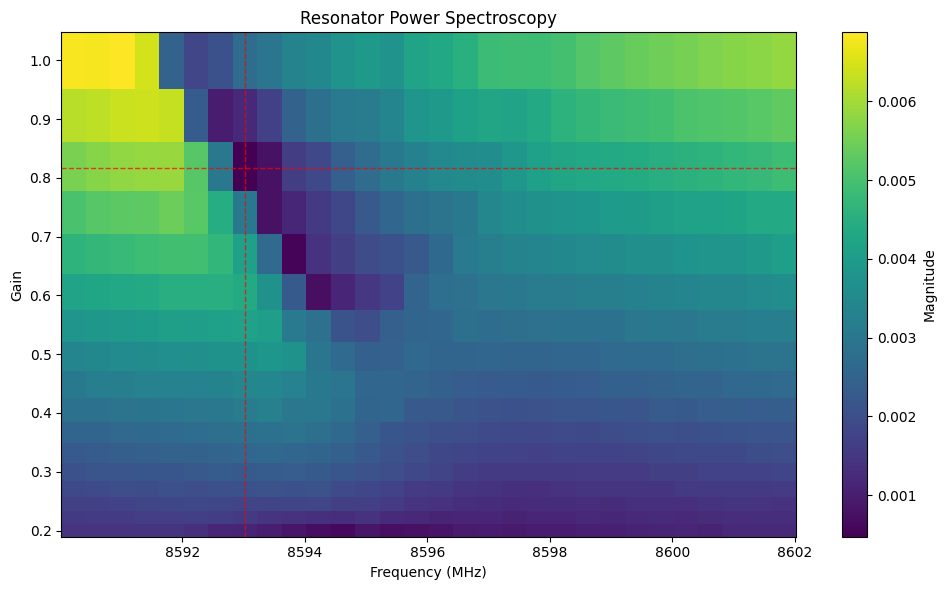

Optimal frequency: 8.593023 GHz
Optimal gain: 0.817765
Runtime attr.ro_fq delta: -3.200 MHz
Stage checkpoint saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_04_resonator_power_chevron.json


In [3]:
power_chevron = ResonatorPowerSpectroscopy(session)
power_chevron_result = power_chevron.run(
    RESONATOR_POWER_READOUT_OP,
    rf_begin=RESONATOR_POWER_RF_BEGIN,
    rf_end=RESONATOR_POWER_RF_END,
    df=RESONATOR_POWER_DF,
    g_min=RESONATOR_POWER_G_MIN,
    g_max=RESONATOR_POWER_G_MAX,
    N_a=RESONATOR_POWER_N_A,
    n_avg=RESONATOR_POWER_N_AVG,
    ro_therm_clks=RESONATOR_POWER_RO_THERM_CLKS,
)
power_chevron_analysis = power_chevron.analyze(power_chevron_result)
power_chevron.plot(power_chevron_analysis)

optimal_freq = float(power_chevron_analysis.metrics.get("optimal_freq", np.nan))
optimal_gain = float(power_chevron_analysis.metrics.get("optimal_gain", np.nan))

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="04_resonator_power_chevron",
    status="characterized",
    summary="Characterized the resonator operating point without applying calibration changes.",
    consumed_inputs={
        "readout_op": RESONATOR_POWER_READOUT_OP,
        "rf_begin_hz": RESONATOR_POWER_RF_BEGIN,
        "rf_end_hz": RESONATOR_POWER_RF_END,
        "df_hz": RESONATOR_POWER_DF,
        "gain_min": RESONATOR_POWER_G_MIN,
        "gain_max": RESONATOR_POWER_G_MAX,
        "gain_samples": RESONATOR_POWER_N_A,
        "n_avg": RESONATOR_POWER_N_AVG,
    },
    persisted_outputs={},
    advisory_outputs={
        "optimal_freq_hz": optimal_freq,
        "optimal_gain": optimal_gain,
    },
    next_stage="05_qubit_spectroscopy_pulse_calibration",
    notes=[
        "This stage is characterization-only in the numbered workflow.",
        "Notebook 05 may use the chosen readout operating point as advisory context, but it must not assume any readout calibration was committed here.",
    ],
    metrics=dict(power_chevron_analysis.metrics),
)

print(f"Optimal frequency: {optimal_freq / 1e9:.6f} GHz")
print(f"Optimal gain: {optimal_gain:.6f}")
print(f"Runtime attr.ro_fq delta: {(optimal_freq - float(attr.ro_fq)) / 1e6:+.3f} MHz")
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 4. Analysis — Chevron Maps

Detailed magnitude and phase color maps with the extracted optimum and runtime frequency overlaid. Use these plots to visually confirm the readout operating point before proceeding to qubit spectroscopy.

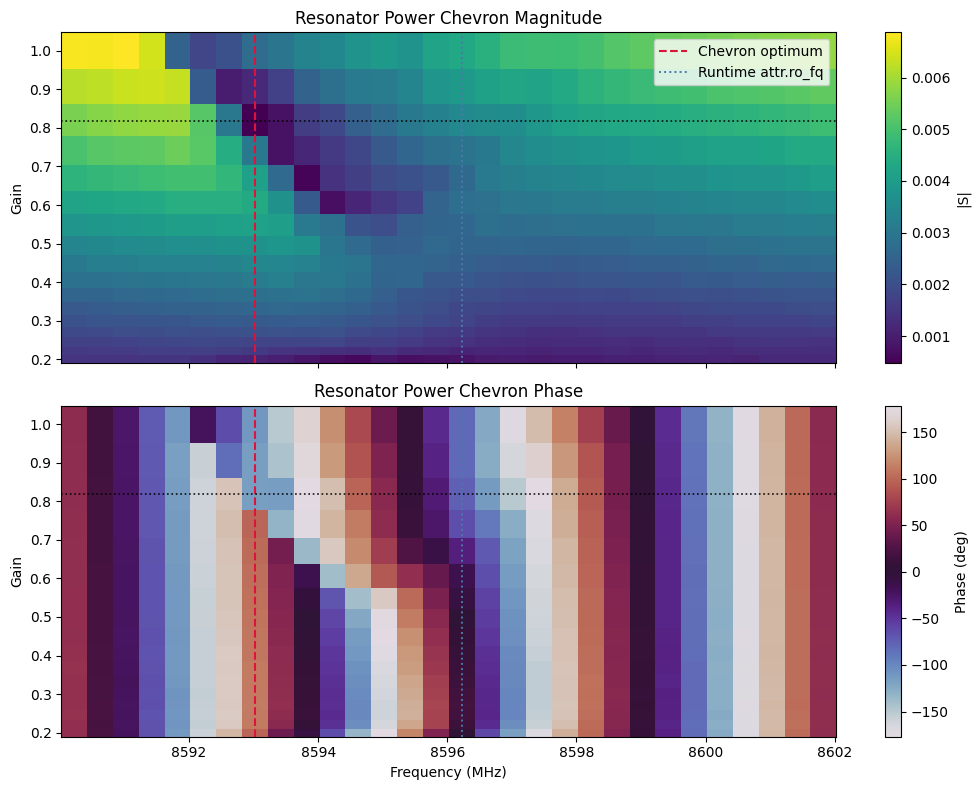

Optimal frequency: 8.593023 GHz
Optimal gain: 0.817765
Runtime delta: -3.200 MHz


In [4]:
if "power_chevron_analysis" not in globals():
    print("Run the power-chevron cell above to generate the magnitude and phase chevron maps.")
else:
    frequencies_hz = np.asarray(power_chevron_analysis.data.get("frequencies", []), dtype=float)
    gains = np.asarray(power_chevron_analysis.data.get("gains", []), dtype=float)
    S = np.asarray(power_chevron_analysis.data.get("S", []))
    if frequencies_hz.size == 0 or gains.size == 0 or S.size == 0:
        raise RuntimeError("Resonator power chevron analysis did not expose frequencies/gains/S for plotting.")

    if S.shape == (frequencies_hz.size, gains.size):
        Z = S.T
    elif S.shape == (gains.size, frequencies_hz.size):
        Z = S
    else:
        raise RuntimeError(f"Unexpected resonator power spectroscopy shape: {S.shape}")

    def centers_to_edges(values: np.ndarray) -> np.ndarray:
        if values.size == 1:
            return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)
        mids = 0.5 * (values[1:] + values[:-1])
        first = values[0] - (mids[0] - values[0])
        last = values[-1] + (values[-1] - mids[-1])
        return np.concatenate(([first], mids, [last]))

    optimal_freq_hz = float(power_chevron_analysis.metrics.get("optimal_freq", np.nan))
    optimal_gain = float(power_chevron_analysis.metrics.get("optimal_gain", np.nan))
    freq_mhz = frequencies_hz / 1e6
    freq_edges_mhz = centers_to_edges(freq_mhz)
    gain_edges = centers_to_edges(gains)
    magnitude = np.abs(Z)
    phase_deg = np.angle(Z, deg=True)

    fig, axes = plt.subplots(2, 1, figsize=(10.5, 8), sharex=True)

    pcm_mag = axes[0].pcolormesh(freq_edges_mhz, gain_edges, magnitude, shading="auto")
    fig.colorbar(pcm_mag, ax=axes[0], label="|S|")
    axes[0].set_ylabel("Gain")
    axes[0].set_title("Resonator Power Chevron Magnitude")

    pcm_phase = axes[1].pcolormesh(freq_edges_mhz, gain_edges, phase_deg, shading="auto", cmap="twilight")
    fig.colorbar(pcm_phase, ax=axes[1], label="Phase (deg)")
    axes[1].set_xlabel("Frequency (MHz)")
    axes[1].set_ylabel("Gain")
    axes[1].set_title("Resonator Power Chevron Phase")

    for ax in axes:
        if np.isfinite(optimal_freq_hz):
            ax.axvline(optimal_freq_hz / 1e6, color="crimson", ls="--", lw=1.5, label="Chevron optimum")
        ax.axvline(float(attr.ro_fq) / 1e6, color="#4c78a8", ls=":", lw=1.4, label="Runtime attr.ro_fq")
        if np.isfinite(optimal_gain):
            ax.axhline(optimal_gain, color="black", ls=":", lw=1.2, alpha=0.9)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles[:2], labels[:2], loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Optimal frequency: {optimal_freq_hz / 1e9:.6f} GHz")
    print(f"Optimal gain: {optimal_gain:.6f}")
    print(f"Runtime delta: {(optimal_freq_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")